In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import matplotlib.ticker as ticker
import numpy as np
import re
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import json
from matplotlib.patches import Patch
import ast
import matplotlib.patches as mpatches

In [13]:
# path = "results/oliver-v2/2026-04-17_18:53:46/"
# path2 = "results/oliver-v2/plot.pdf"
path = "results/oliver-v3/2026-05-09_00:26:49/"
path2 = "results/oliver-v3/plot.pdf"

In [14]:
columns = [
    "type", "avg", "std", "min", "p5", "p10", "p50", "p67", "p75", "p80",
    "p85", "p90", "p95", "p99", "p999", "p9999", "QPS", "target", "ts_end", "ts_start"
]

In [15]:
mcperf_df = pd.read_csv(
    path + "mcperf.txt",
    delim_whitespace=True
)

mcperf_df["ts_start"] = mcperf_df["ts_start"] / 1000
mcperf_df["ts_end"] = mcperf_df["ts_end"] / 1000

mcperf_df

/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48644/993256791.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mcperf_df = pd.read_csv(


,#type,avg,std,min,p5,p10,p50,p67,p75,p80,p85,p90,p95,p99,p999,p9999,QPS,target,ts_start,ts_end
0,read,225.8,86.0,93.8,141.2,153.4,218.9,246.7,262.0,272.4,285.5,300.9,325.7,391.7,718.0,3200.0,30013.6,30000,1.778278e+09,1.778278e+09
1,read,229.7,87.0,86.8,142.4,155.1,221.6,250.4,266.5,277.5,291.4,309.4,337.5,406.5,717.0,3358.4,30093.1,30005,1.778278e+09,1.778278e+09
2,read,232.0,84.4,86.8,145.1,157.8,223.5,252.2,268.5,280.1,293.9,312.4,340.6,413.8,689.5,3162.6,29972.7,30010,1.778278e+09,1.778279e+09
3,read,235.7,88.5,86.8,145.6,159.8,227.8,256.9,272.5,284.5,297.3,315.6,343.7,423.0,745.7,3593.3,30063.2,30015,1.778279e+09,1.778279e+09
4,read,227.9,95.2,86.8,143.5,156.0,218.6,246.3,262.3,273.3,287.7,305.4,333.8,404.6,724.1,4214.7,30138.3,30020,1.778279e+09,1.778279e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,read,235.2,137.1,86.8,144.4,157.0,221.9,251.6,268.2,280.0,294.0,312.5,341.0,429.0,2735.1,3808.5,30362.4,30290,1.778279e+09,1.778279e+09
59,read,234.9,190.0,86.8,144.1,155.4,214.2,242.5,259.5,271.7,287.1,307.0,339.9,479.2,3275.3,6236.1,30266.4,30295,1.778279e+09,1.778279e+09
60,read,261.4,256.2,93.8,146.1,158.9,228.7,261.5,280.4,294.4,312.1,336.1,383.6,960.6,3934.0,6966.4,30335.7,30300,1.778279e+09,1.778279e+09
61,read,236.5,156.7,86.8,144.8,156.3,218.5,248.4,265.4,277.2,292.5,312.3,343.7,499.6,2784.3,5909.4,30330.1,30305,1.778279e+09,1.778279e+09


In [16]:
import re

def parse_taskset_cores(item):
    """
    Extract cores from a Kubernetes pod spec command like:
    taskset -c 0-7 ./run ...
    taskset -c 1 ./run ...
    taskset -c 1-3 ./run ...

    Returns a list of ints, e.g. [0, 1, 2, 3].
    """
    containers = item["spec"].get("containers", [])
    if not containers:
        return []

    args = containers[0].get("args", [])
    command_string = " ".join(args)

    match = re.search(r"taskset\s+-c\s+([0-9,\-]+)", command_string)
    if not match:
        return []

    core_string = match.group(1)

    cores = []
    for part in core_string.split(","):
        if "-" in part:
            start, end = map(int, part.split("-"))
            cores.extend(range(start, end + 1))
        else:
            cores.append(int(part))

    return cores

In [17]:
with open(path + "pods.json") as f:
    pods = json.load(f)

rows = []

for item in pods["items"]:

    name = item["metadata"]["name"]

    # job name
    if "job-name" in item["metadata"].get("labels", {}):
        job = item["metadata"]["labels"]["job-name"]
    else:
        job = name  # memcached
    if job == "some-memcached":
        continue

    machine = item["spec"]["nodeName"]

    cores = parse_taskset_cores(item)

    status = item["status"]["containerStatuses"][0]["state"]

    if "terminated" in status:

        start = status["terminated"]["startedAt"]
        end = status["terminated"]["finishedAt"]

    elif "running" in status:

        start = status["running"]["startedAt"]
        end = None

    else:
        continue

    rows.append({
        "job": job,
        "machine": machine,
        "cores": cores,
        "ts_start": start,
        "ts_end": end,
    })

schedule_df = pd.DataFrame(rows)

schedule_df["ts_start"] = pd.to_datetime(schedule_df["ts_start"])
schedule_df["ts_end"] = pd.to_datetime(schedule_df["ts_end"])

final_time = mcperf_df["ts_end"].max()

schedule_df["ts_end"] = schedule_df["ts_end"].fillna(
    pd.to_datetime(final_time, unit="s")
)

# schedule_df["ts_start"] = schedule_df["ts_start"].astype("int64") / 1e9
# schedule_df["ts_end"] = schedule_df["ts_end"].astype("int64") / 1e9

schedule_df["ts_start"] = schedule_df["ts_start"].apply(lambda x: x.timestamp())
schedule_df["ts_end"] = schedule_df["ts_end"].apply(lambda x: x.timestamp())

# node-a-8core-lm9f -> node-a-8core
schedule_df["machine"] = schedule_df["machine"].str.replace(r"(core).*", r"\1", regex=True)

schedule_df

,job,machine,cores,ts_start,ts_end
0,parsec-barnes,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09
1,parsec-blackscholes,node-b-4core,[1],1.778279e+09,1.778279e+09
2,parsec-canneal,node-b-4core,"[2, 3]",1.778279e+09,1.778279e+09
3,parsec-freqmine,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09
4,parsec-radix,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09
5,parsec-streamcluster,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09
6,parsec-vips,node-b-4core,"[1, 2, 3]",1.778279e+09,1.778279e+09


In [18]:
t0 = min(
    mcperf_df["ts_start"].min(),
    schedule_df["ts_start"].min()
)

tn = max(
    mcperf_df["ts_end"].max(),
    schedule_df["ts_end"].max()
)

schedule_df.loc[len(schedule_df)] = {
    "job": "memcached",
    "machine": "node-b-4core",
    "cores": [0],
    "ts_start": t0,
    "ts_end": tn
}

mcperf_df["x0"] = mcperf_df["ts_start"] - t0
schedule_df["x0"] = schedule_df["ts_start"] - t0

mcperf_df["width"] = mcperf_df["ts_end"] - mcperf_df["ts_start"]
schedule_df["width"] = schedule_df["ts_end"] - schedule_df["ts_start"]
t0

1778278472.971

In [19]:
schedule_df

,job,machine,cores,ts_start,ts_end,x0,width
0,parsec-barnes,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09,583.029,23.000
1,parsec-blackscholes,node-b-4core,[1],1.778279e+09,1.778279e+09,513.029,108.000
2,parsec-canneal,node-b-4core,"[2, 3]",1.778279e+09,1.778279e+09,512.029,143.000
3,parsec-freqmine,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09,512.029,68.000
4,parsec-radix,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09,609.029,6.000
5,parsec-streamcluster,node-a-8core,"[0, 1, 2, 3, 4, 5, 6, 7]",1.778279e+09,1.778279e+09,618.029,100.000
6,parsec-vips,node-b-4core,"[1, 2, 3]",1.778279e+09,1.778279e+09,658.029,66.000
7,memcached,node-b-4core,[0],1.778278e+09,1.778279e+09,0.000,731.161


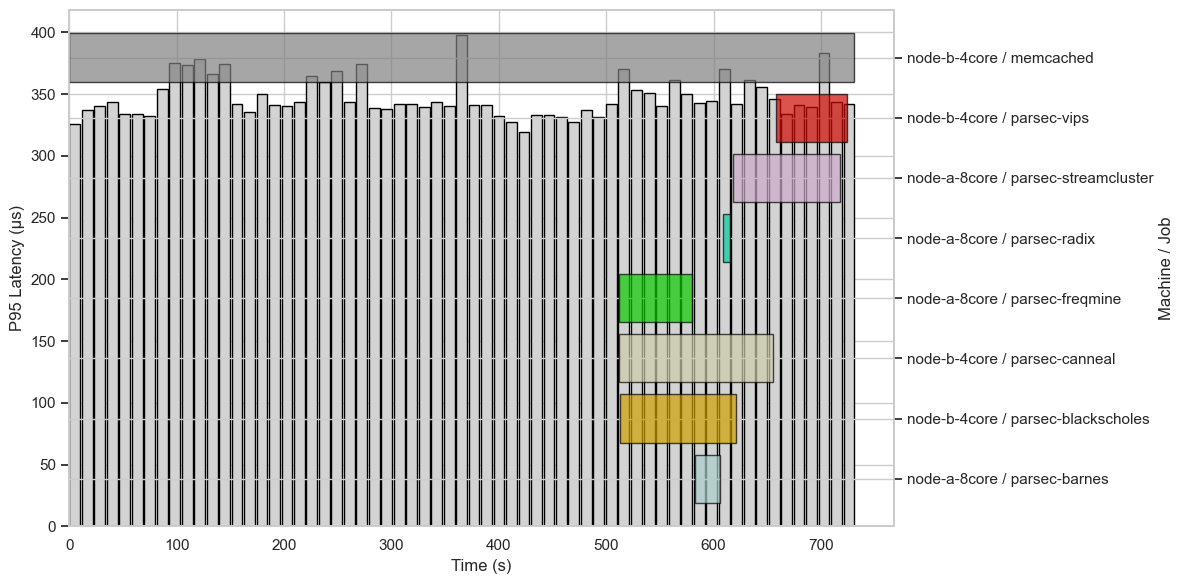

In [20]:
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

schedule_df["label"] = schedule_df["machine"] + " / " + schedule_df["job"]
job_colors = {
    "parsec-barnes": "#AACCCA",
    "parsec-blackscholes": "#CCA000",
    "parsec-canneal": "#CCCCAA",
    "parsec-freqmine": "#0CCA00",
    "parsec-radix": "#00CCA0",
    "parsec-streamcluster": "#CCACCA",
    "parsec-vips": "#CC0A00",
    "memcached": "#808080"  # optional gray
}

colors = schedule_df["job"].map(job_colors).fillna("lightgray")

# --- Vertical latency bars ---
ax1.bar(
    x=mcperf_df["x0"],
    height=mcperf_df["p95"],
    width=mcperf_df["width"],
    align="edge",
    edgecolor="black",
    color="lightgray",
    zorder=1
)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("P95 Latency (μs)")

# --- Second axis ON TOP ---
ax2 = ax1.twinx()



# Horizontal schedule bars
ax2.barh(
    y=schedule_df["label"],
    width=schedule_df["width"],
    left=schedule_df["x0"],
    edgecolor="black",
    color=colors,
    zorder=2,
    alpha=0.7
)

ax2.set_ylabel("Machine / Job")

# Optional: keep job bars visually on top
ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False)

plt.tight_layout()
plt.savefig(path2)
plt.show()

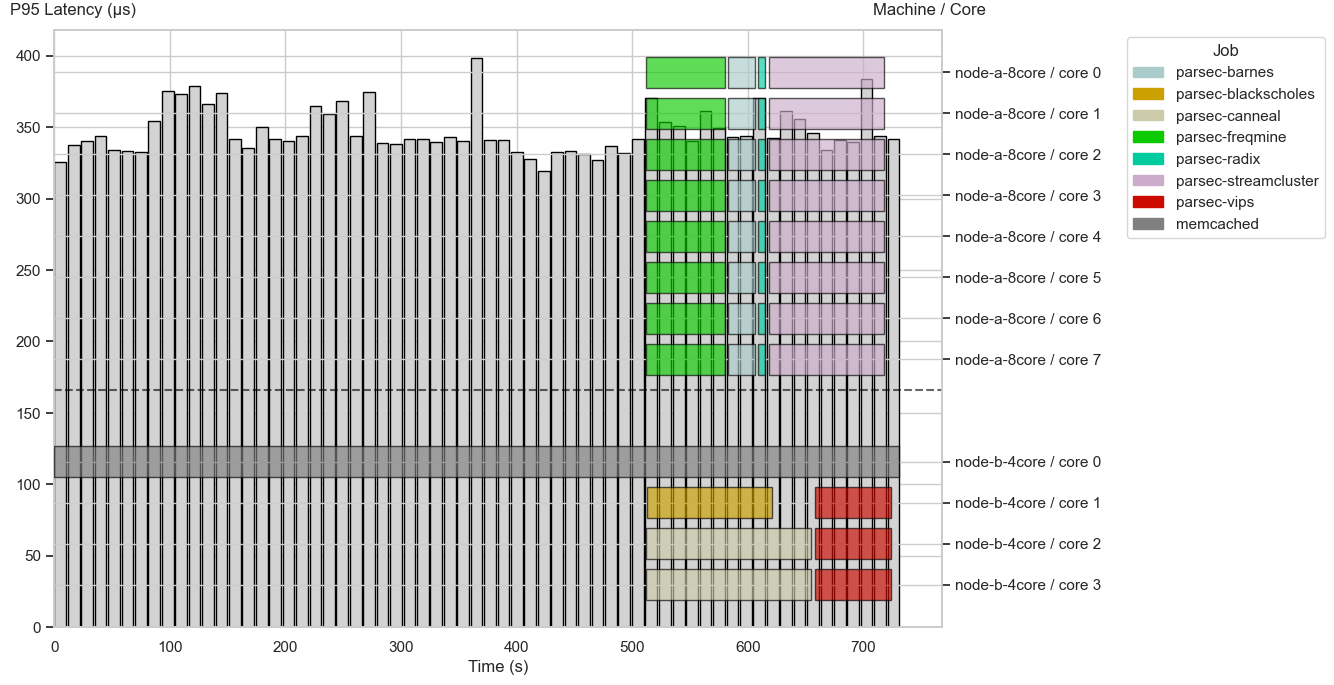

In [21]:
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(14, 7))

job_colors = {
    "parsec-barnes": "#AACCCA",
    "parsec-blackscholes": "#CCA000",
    "parsec-canneal": "#CCCCAA",
    "parsec-freqmine": "#0CCA00",
    "parsec-radix": "#00CCA0",
    "parsec-streamcluster": "#CCACCA",
    "parsec-vips": "#CC0A00",
    "memcached": "#808080"
}

# --------------------------------------------------
# Helper: make sure cores are real Python lists
# --------------------------------------------------
def parse_core_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return []

schedule_df = schedule_df.copy()
schedule_df["cores"] = schedule_df["cores"].apply(parse_core_list)

# --------------------------------------------------
# First axis: vertical latency bars
# --------------------------------------------------
ax1.bar(
    x=mcperf_df["x0"],
    height=mcperf_df["p95"],
    width=mcperf_df["width"],
    align="edge",
    edgecolor="black",
    color="lightgray",
    zorder=1
)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel(
    "P95 Latency (μs)",
    rotation=0,     # horizontal
    labelpad=60,    # move away from axis
    ha="left",
    va="bottom"
)

ax1.yaxis.set_label_coords(-0.05, 1.02)

# --------------------------------------------------
# Second axis: core-level schedule bars
# --------------------------------------------------
ax2 = ax1.twinx()

# Define machine order manually
machine_order = ["node-a-8core", "node-b-4core"]

# Build y positions
y_positions = {}
y_labels = []

y = 0
gap = 1.5

for machine in machine_order:
    machine_cores = sorted(
        {
            core
            for cores in schedule_df.loc[schedule_df["machine"] == machine, "cores"]
            for core in cores
        }
    )

    for core in machine_cores:
        key = (machine, core)
        y_positions[key] = y
        y_labels.append(f"{machine} / core {core}")
        y += 1

    y += gap   # visual separation between machines

# Draw one bar per active core
for _, row in schedule_df.iterrows():
    machine = row["machine"]
    job = row["job"]
    x0 = row["x0"]
    width = row["width"]
    color = job_colors.get(job, "lightgray")

    for core in row["cores"]:
        key = (machine, core)

        if key not in y_positions:
            continue

        ax2.barh(
            y=y_positions[key],
            width=width,
            left=x0,
            height=0.75,
            color=color,
            edgecolor="black",
            alpha=0.65,
            zorder=3
        )

# Y-axis formatting
ax2.set_yticks(list(y_positions.values()))
ax2.set_yticklabels(y_labels)
ax2.set_ylabel(
    "Machine / Core",
    rotation=0,     # horizontal
    labelpad=60,    # move away from axis
    ha="right",
    va="bottom"
)

ax2.yaxis.set_label_coords(1.05, 1.02)

# Put node-a at the top
ax2.invert_yaxis()

# Keep schedule bars visually on top
ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False)

# Optional separator line between machines
node_a_ys = [
    y_positions[key]
    for key in y_positions
    if key[0] == "node-a-8core"
]

if node_a_ys:
    separator_y = max(node_a_ys) + gap / 2
    ax2.axhline(
        separator_y,
        color="black",
        linewidth=1.5,
        linestyle="--",
        alpha=0.6
    )

# Optional legend for jobs
legend_handles = [
    mpatches.Patch(color=color, label=job)
    for job, color in job_colors.items()
    if job in schedule_df["job"].values
]

ax2.legend(
    handles=legend_handles,
    title="Job",
    bbox_to_anchor=(1.2, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(path2, bbox_inches="tight")
plt.show()

# Get 3 Plots

In [27]:
def plot_usage(schedule_df, mcperf_df, path2, tn, folder_name):
    sns.set_theme(style="whitegrid")

    fig, ax1 = plt.subplots(figsize=(14, 7))

    job_colors = {
        "barnes": "#AACCCA",
        "blackscholes": "#CCA000",
        "canneal": "#CCCCAA",
        "freqmine": "#0CCA00",
        "radix": "#00CCA0",
        "streamcluster": "#CCACCA",
        "vips": "#CC0A00",
        "memcached": "#808080"
    }

    if "2026-05-04_21:31:34" in folder_name:
        run = 2
    elif "2026-05-04_21:22:22" in folder_name:
        run = 1
    else:
        run = 3

    # if "2026-04-18_12:40:47" in folder_name:
    #     run = 0
    # elif "2026-04-18_12:49:37" in folder_name:
    #     run = 1
    # elif "2026-05-09_00:26:49" in folder_name:
    #     run = 2
    # else:
    #     run = 3

    # --------------------------------------------------
    # Helper: make sure cores are real Python lists
    # --------------------------------------------------
    def parse_core_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return ast.literal_eval(x)
        return []

    schedule_df = schedule_df.copy()
    schedule_df["cores"] = schedule_df["cores"].apply(parse_core_list)

    # --------------------------------------------------
    # First axis: vertical latency bars
    # --------------------------------------------------
    ax1.bar(
        x=mcperf_df["x0"],
        height=mcperf_df["p95"],
        width=mcperf_df["width"],
        align="edge",
        edgecolor="black",
        color="lightgray",
        zorder=1
    )

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel(
        "P95 Latency (ms)",
        rotation=0,     # horizontal
        labelpad=60,    # move away from axis
        ha="left",
        va="bottom"
    )

    ax1.yaxis.set_label_coords(-0.05, 1.02)

    # --------------------------------------------------
    # Second axis: core-level schedule bars
    # --------------------------------------------------
    ax2 = ax1.twinx()

    ax2.grid(False)

    # Force x-axis to start at 0
    ax1.set_xlim(left=-2, right=tn + 2)
    ax2.set_xlim(left=-2, right=tn + 2)

    # Define machine order manually
    machine_order = ["node-a-8core", "node-b-4core"]

    # Build y positions
    y_positions = {}
    y_labels = []

    y = 0
    gap = 1.5

    for machine in machine_order:
        machine_cores = sorted(
            {
                core
                for cores in schedule_df.loc[schedule_df["machine"] == machine, "cores"]
                for core in cores
            }
        )

        for core in machine_cores:
            key = (machine, core)
            y_positions[key] = y
            y_labels.append(f"{machine} / core {core}")
            y += 1

        y += gap   # visual separation between machines

    # Draw one bar per active core
    for _, row in schedule_df.iterrows():
        machine = row["machine"]
        job = row["job"]
        x0 = row["x0"]
        width = row["width"]
        color = job_colors.get(job, "lightgray")

        for core in row["cores"]:
            key = (machine, core)

            if key not in y_positions:
                continue

            ax2.barh(
                y=y_positions[key],
                width=width,
                left=x0,
                height=0.75,
                color=color,
                edgecolor="black",
                alpha=0.65,
                zorder=3
            )

    # Y-axis formatting
    ax2.set_yticks(list(y_positions.values()))
    ax2.set_yticklabels(y_labels)
    ax2.set_ylabel(
        "Machine / Core",
        rotation=0,     # horizontal
        labelpad=60,    # move away from axis
        ha="right",
        va="bottom"
    )

    ax2.yaxis.set_label_coords(1.05, 1.02)

    # Put node-a at the top
    ax2.invert_yaxis()

    # Keep schedule bars visually on top
    ax2.set_zorder(ax1.get_zorder() + 1)
    ax2.patch.set_visible(False)

    # Optional separator line between machines
    node_a_ys = [
        y_positions[key]
        for key in y_positions
        if key[0] == "node-a-8core"
    ]

    if node_a_ys:
        separator_y = max(node_a_ys) + gap / 2
        ax2.axhline(
            separator_y,
            color="black",
            linewidth=1.5,
            linestyle="--",
            alpha=0.6
        )

    # Optional legend for jobs
    legend_handles = [
        mpatches.Patch(color=color, label=job)
        for job, color in job_colors.items()
        if job in schedule_df["job"].values
    ]

    ax2.legend(
        handles=legend_handles,
        title="Job",
        bbox_to_anchor=(1.2, 1),
        loc="upper left"
    )

    # ax1.set_title(
    #     f"Run {run} of our Scheduling Policy",
    #     fontsize=16,
    #     pad=25,
    #     x=0.112
    # )

    ax1.set_title(
        f"Run {run} of OpenEvolves Best Policy",
        fontsize=16,
        pad=25,
        x=0.13
    )

    plt.tight_layout()
    plt.savefig(path2, bbox_inches="tight")
    plt.show()

In [28]:
def create_mcperf_df(path):
    mcperf_df = pd.read_csv(
        path + "/mcperf.txt",
        delim_whitespace=True
    )

    # print(mcperf_df)

    mcperf_df["p95"] = mcperf_df["p95"]/1000

    mcperf_df["ts_start"] = mcperf_df["ts_start"] / 1000
    mcperf_df["ts_end"] = mcperf_df["ts_end"] / 1000

    return mcperf_df

In [29]:
def create_schedule_df(path):
    with open(path + "/pods.json") as f:
        pods = json.load(f)

    rows = []

    for item in pods["items"]:

        name = item["metadata"]["name"]

        # job name
        if "job-name" in item["metadata"].get("labels", {}):
            job = item["metadata"]["labels"]["job-name"]
        else:
            job = name  # memcached
        if job == "some-memcached":
            continue

        machine = item["spec"]["nodeName"]

        cores = parse_taskset_cores(item)

        status = item["status"]["containerStatuses"][0]["state"]

        if "terminated" in status:

            start = status["terminated"]["startedAt"]
            end = status["terminated"]["finishedAt"]

        elif "running" in status:

            start = status["running"]["startedAt"]
            end = None

        else:
            continue

        rows.append({
            "job": job,
            "machine": machine,
            "cores": cores,
            "ts_start": start,
            "ts_end": end,
        })

    schedule_df = pd.DataFrame(rows)

    schedule_df["job"] = schedule_df["job"].str.removeprefix("parsec-")

    schedule_df["ts_start"] = pd.to_datetime(schedule_df["ts_start"])
    schedule_df["ts_end"] = pd.to_datetime(schedule_df["ts_end"])

    final_time = mcperf_df["ts_end"].max()

    schedule_df["ts_end"] = schedule_df["ts_end"].fillna(
        pd.to_datetime(final_time, unit="s")
    )

    # schedule_df["ts_start"] = schedule_df["ts_start"].astype("int64") / 1e9
    # schedule_df["ts_end"] = schedule_df["ts_end"].astype("int64") / 1e9

    schedule_df["ts_start"] = schedule_df["ts_start"].apply(lambda x: x.timestamp())
    schedule_df["ts_end"] = schedule_df["ts_end"].apply(lambda x: x.timestamp())

    # node-a-8core-lm9f -> node-a-8core
    schedule_df["machine"] = schedule_df["machine"].str.replace(r"(core).*", r"\1", regex=True)

    print(schedule_df)

    return schedule_df

In [30]:
def normalize_timing(mcperf_df, schedule_df):
    # t0 = min(
    #     mcperf_df["ts_start"].min(),
    #     schedule_df["ts_start"].min()
    # )

    t0 = schedule_df["ts_start"].min()

    # tn = max(
    #     mcperf_df["ts_end"].max(),
    #     schedule_df["ts_end"].max()
    # )

    tn = schedule_df["ts_end"].max()

    schedule_df.loc[len(schedule_df)] = {
        "job": "memcached",
        "machine": "node-b-4core",
        "cores": [0],
        "ts_start": t0 - 5,
        "ts_end": tn + 5
    }

    mcperf_df["x0"] = mcperf_df["ts_start"] - t0
    schedule_df["x0"] = schedule_df["ts_start"] - t0

    mcperf_df["width"] = mcperf_df["ts_end"] - mcperf_df["ts_start"]
    schedule_df["width"] = schedule_df["ts_end"] - schedule_df["ts_start"]

    tn = tn - t0

    return tn

results/openevolve-best/2026-05-04_21:31:34
             job       machine         cores      ts_start        ts_end
0         barnes  node-a-8core  [4, 5, 6, 7]  1.777923e+09  1.777923e+09
1   blackscholes  node-a-8core  [0, 1, 2, 3]  1.777923e+09  1.777923e+09
2        canneal  node-a-8core  [0, 1, 2, 3]  1.777923e+09  1.777923e+09
3       freqmine  node-a-8core  [4, 5, 6, 7]  1.777923e+09  1.777923e+09
4          radix  node-a-8core           [0]  1.777923e+09  1.777923e+09
5  streamcluster  node-b-4core     [1, 2, 3]  1.777923e+09  1.777923e+09
6           vips  node-a-8core  [4, 5, 6, 7]  1.777923e+09  1.777923e+09


/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48644/892832691.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mcperf_df = pd.read_csv(


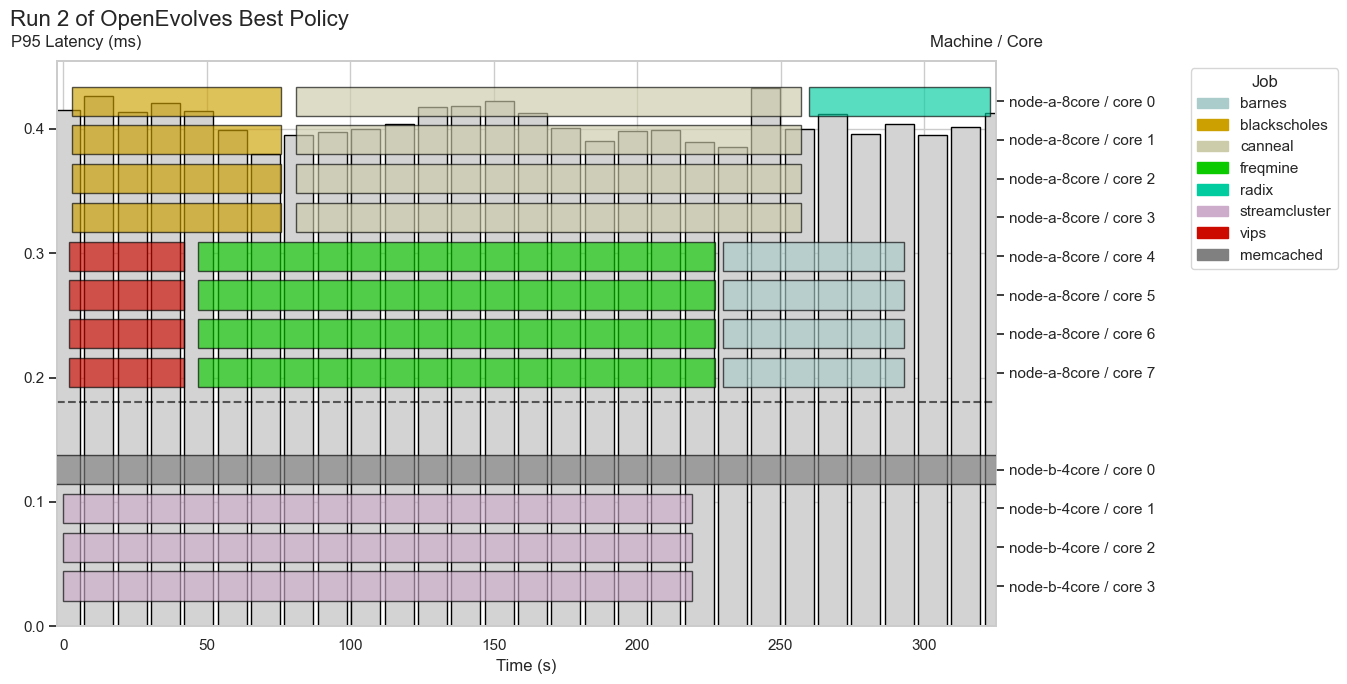

results/openevolve-best/2026-05-12_20:50:19
             job       machine         cores      ts_start        ts_end
0         barnes  node-a-8core  [4, 5, 6, 7]  1.778612e+09  1.778612e+09
1   blackscholes  node-a-8core  [0, 1, 2, 3]  1.778612e+09  1.778612e+09
2        canneal  node-a-8core  [0, 1, 2, 3]  1.778612e+09  1.778612e+09
3       freqmine  node-a-8core  [4, 5, 6, 7]  1.778612e+09  1.778612e+09
4          radix  node-a-8core           [0]  1.778612e+09  1.778612e+09
5  streamcluster  node-b-4core     [1, 2, 3]  1.778612e+09  1.778612e+09
6           vips  node-a-8core  [4, 5, 6, 7]  1.778612e+09  1.778612e+09


/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48644/892832691.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mcperf_df = pd.read_csv(


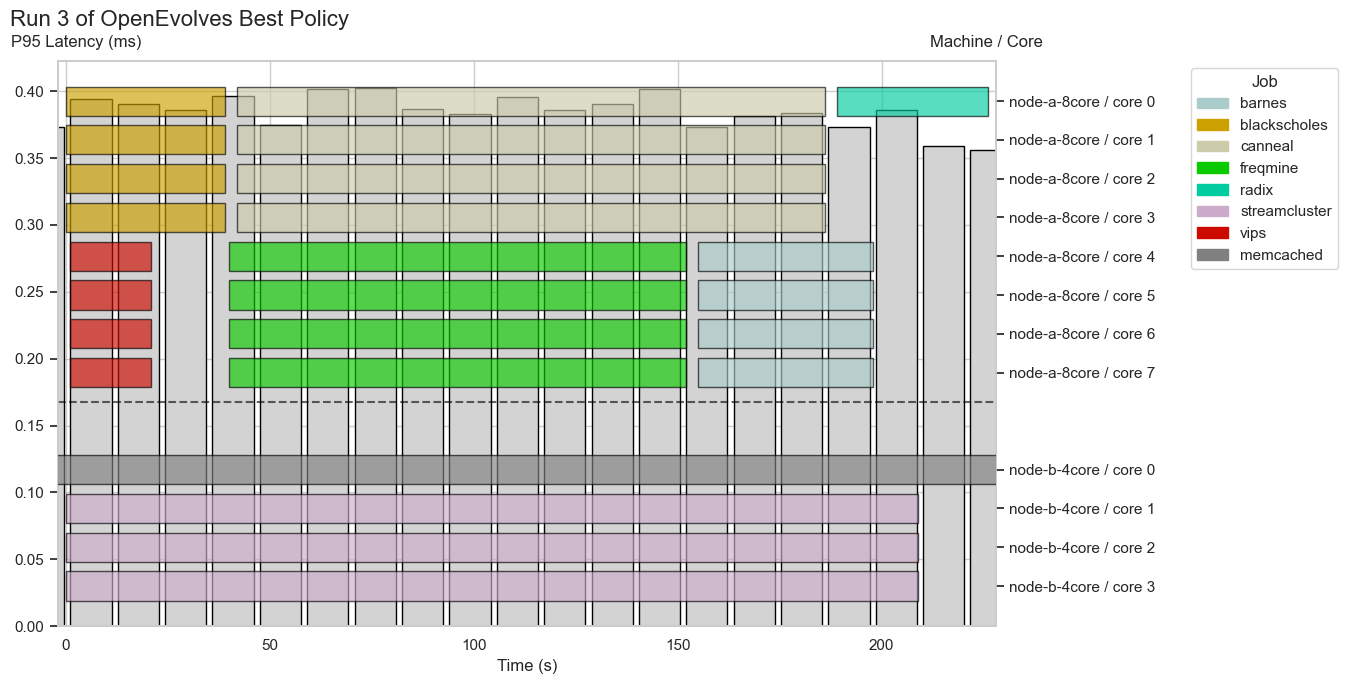

results/openevolve-best/2026-05-04_21:22:22
             job       machine         cores      ts_start        ts_end
0         barnes  node-a-8core  [4, 5, 6, 7]  1.777922e+09  1.777923e+09
1   blackscholes  node-a-8core  [0, 1, 2, 3]  1.777922e+09  1.777922e+09
2        canneal  node-a-8core  [0, 1, 2, 3]  1.777922e+09  1.777922e+09
3       freqmine  node-a-8core  [4, 5, 6, 7]  1.777922e+09  1.777922e+09
4          radix  node-a-8core           [0]  1.777922e+09  1.777923e+09
5  streamcluster  node-b-4core     [1, 2, 3]  1.777922e+09  1.777922e+09
6           vips  node-a-8core  [4, 5, 6, 7]  1.777922e+09  1.777922e+09


/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_48644/892832691.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mcperf_df = pd.read_csv(


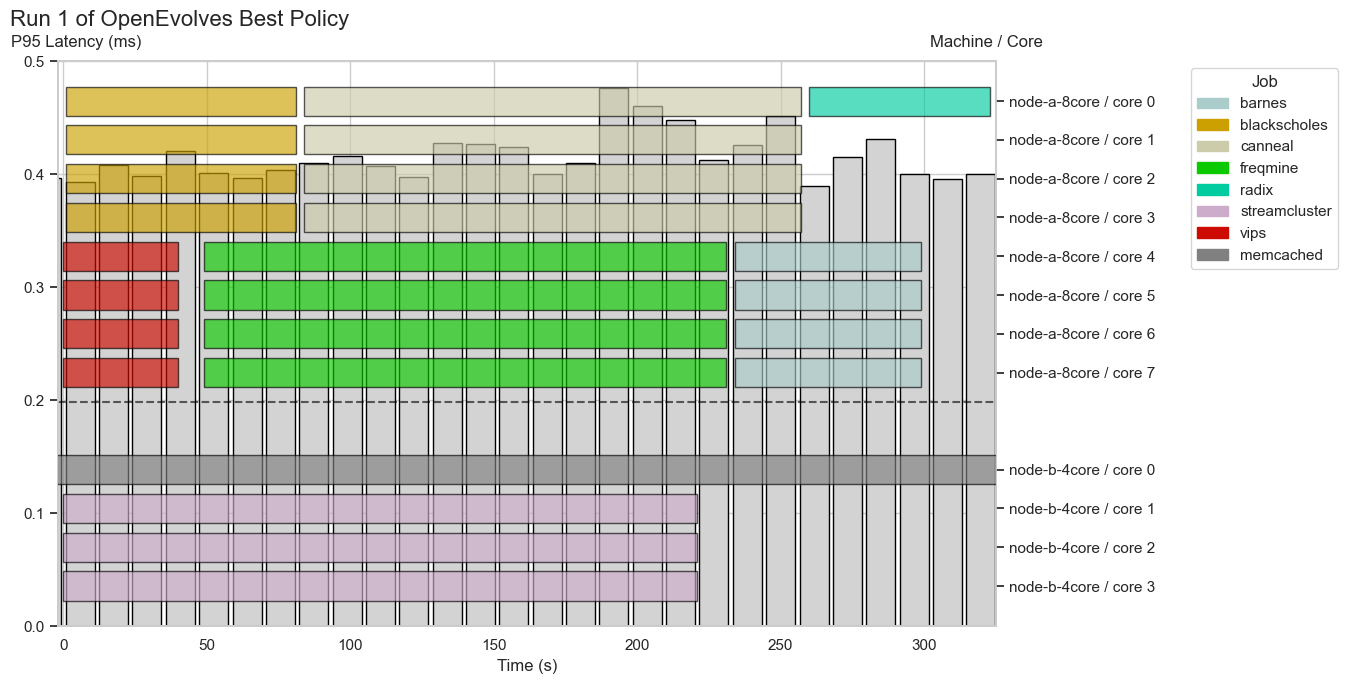

In [31]:
def get_all_plots(path):
    base_folder = Path(path)
    int = 0

    for subfolder in base_folder.iterdir():
        if subfolder.is_dir():
            try:
                print(subfolder)
                path2 = str(base_folder) + "/plot" + str(int) + ".pdf"
                # print(path2)
                mcperf_df = create_mcperf_df(str(subfolder))
                #print(mcperf_df)
                schedule_df = create_schedule_df(str(subfolder))
                # print(create_schedule_df)
                # print(mcperf_df)
                tn = normalize_timing(mcperf_df, schedule_df)
                plot_usage(schedule_df, mcperf_df, path2, tn, str(subfolder))
                int += 1
            except:
                pass

get_all_plots("results/openevolve-best")